# Graph 1 ABCDEF

Simple matplotlib plots from `runner_May1st_processed`.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["legend.fontsize"] = 10

In [2]:
processed_root = Path("/Users/patange/Documents/Argonne/QEC/log/runner_May1st_processed")

rows = []

for sweep_dir in sorted(processed_root.iterdir()):
    if not sweep_dir.is_dir():
        continue

    for path in sorted(sweep_dir.iterdir()):
        if not path.is_file():
            continue

        text = path.read_text().strip()
        latency_ps, fidelity_corrected, rows_processed = [part.strip() for part in text.split(",")]

        name = path.name
        nodes = int(re.search(r"line_(\d+)_2G", name).group(1))

        if sweep_dir.name == "graph_initialization_fidelity_sweep":
            sweep_value = float(re.search(r"(?:^|,)prep=([^,]+)", name).group(1))
        elif sweep_dir.name == "graph_measurement_fidelity_sweep":
            sweep_value = float(re.search(r"(?:^|,)meas=([^,]+)", name).group(1))
        elif sweep_dir.name == "graph_physical_bell_pair_fidelity_sweep":
            sweep_value = float(re.search(r"(?:^|,)physbell=([^,]+)", name).group(1))
        elif sweep_dir.name == "one_qubit_gate_sweep":
            sweep_value = float(re.search(r"(?:^|,)gate=([^,]+)", name).group(1))
        elif sweep_dir.name == "t2_sweep":
            sweep_value = float(re.search(r"(?:^|,)T2=([^,]+)", name).group(1))
        elif sweep_dir.name == "two_qubit_gate_sweep":
            sweep_value = float(re.search(r"(?:^|,)twoq=([^,]+)", name).group(1))
        else:
            continue

        rows.append(
            {
                "sweep_name": sweep_dir.name,
                "nodes": nodes,
                "sweep_value": sweep_value,
                "latency_ps": float(latency_ps),
                "fidelity_corrected": float(fidelity_corrected),
                "rows_processed": int(rows_processed),
                "log_name": name,
            }
        )

df = pd.DataFrame(rows).sort_values(["sweep_name", "nodes", "sweep_value"]).reset_index(drop=True)
df.head()

,sweep_name,nodes,sweep_value,latency_ps,fidelity_corrected,rows_processed,log_name
0,graph_initialization_fidelity_sweep,2,0.990,3.050643e+09,0.999084,87336,"line_2_2G,code=[[7,1,3]],dist=0.001,gate=1.0,t..."
1,graph_initialization_fidelity_sweep,2,0.991,3.067101e+09,0.999300,85709,"line_2_2G,code=[[7,1,3]],dist=0.001,gate=1.0,t..."
2,graph_initialization_fidelity_sweep,2,0.992,3.063795e+09,0.999385,86151,"line_2_2G,code=[[7,1,3]],dist=0.001,gate=1.0,t..."
3,graph_initialization_fidelity_sweep,2,0.993,3.064314e+09,0.999559,86179,"line_2_2G,code=[[7,1,3]],dist=0.001,gate=1.0,t..."
4,graph_initialization_fidelity_sweep,2,0.994,3.057549e+09,0.999629,86346,"line_2_2G,code=[[7,1,3]],dist=0.001,gate=1.0,t..."


In [3]:
init_df = df[df["sweep_name"] == "graph_initialization_fidelity_sweep"].copy()
meas_df = df[df["sweep_name"] == "graph_measurement_fidelity_sweep"].copy()
bell_df = df[df["sweep_name"] == "graph_physical_bell_pair_fidelity_sweep"].copy()
oneq_df = df[df["sweep_name"] == "one_qubit_gate_sweep"].copy()
t2_df = df[df["sweep_name"] == "t2_sweep"].copy()
twoq_df = df[df["sweep_name"] == "two_qubit_gate_sweep"].copy()

node_colors = {2: "#1b3a57", 3: "#b55239", 6: "#2a7f62"}
node_markers = {2: "o", 3: "s", 6: "^"}

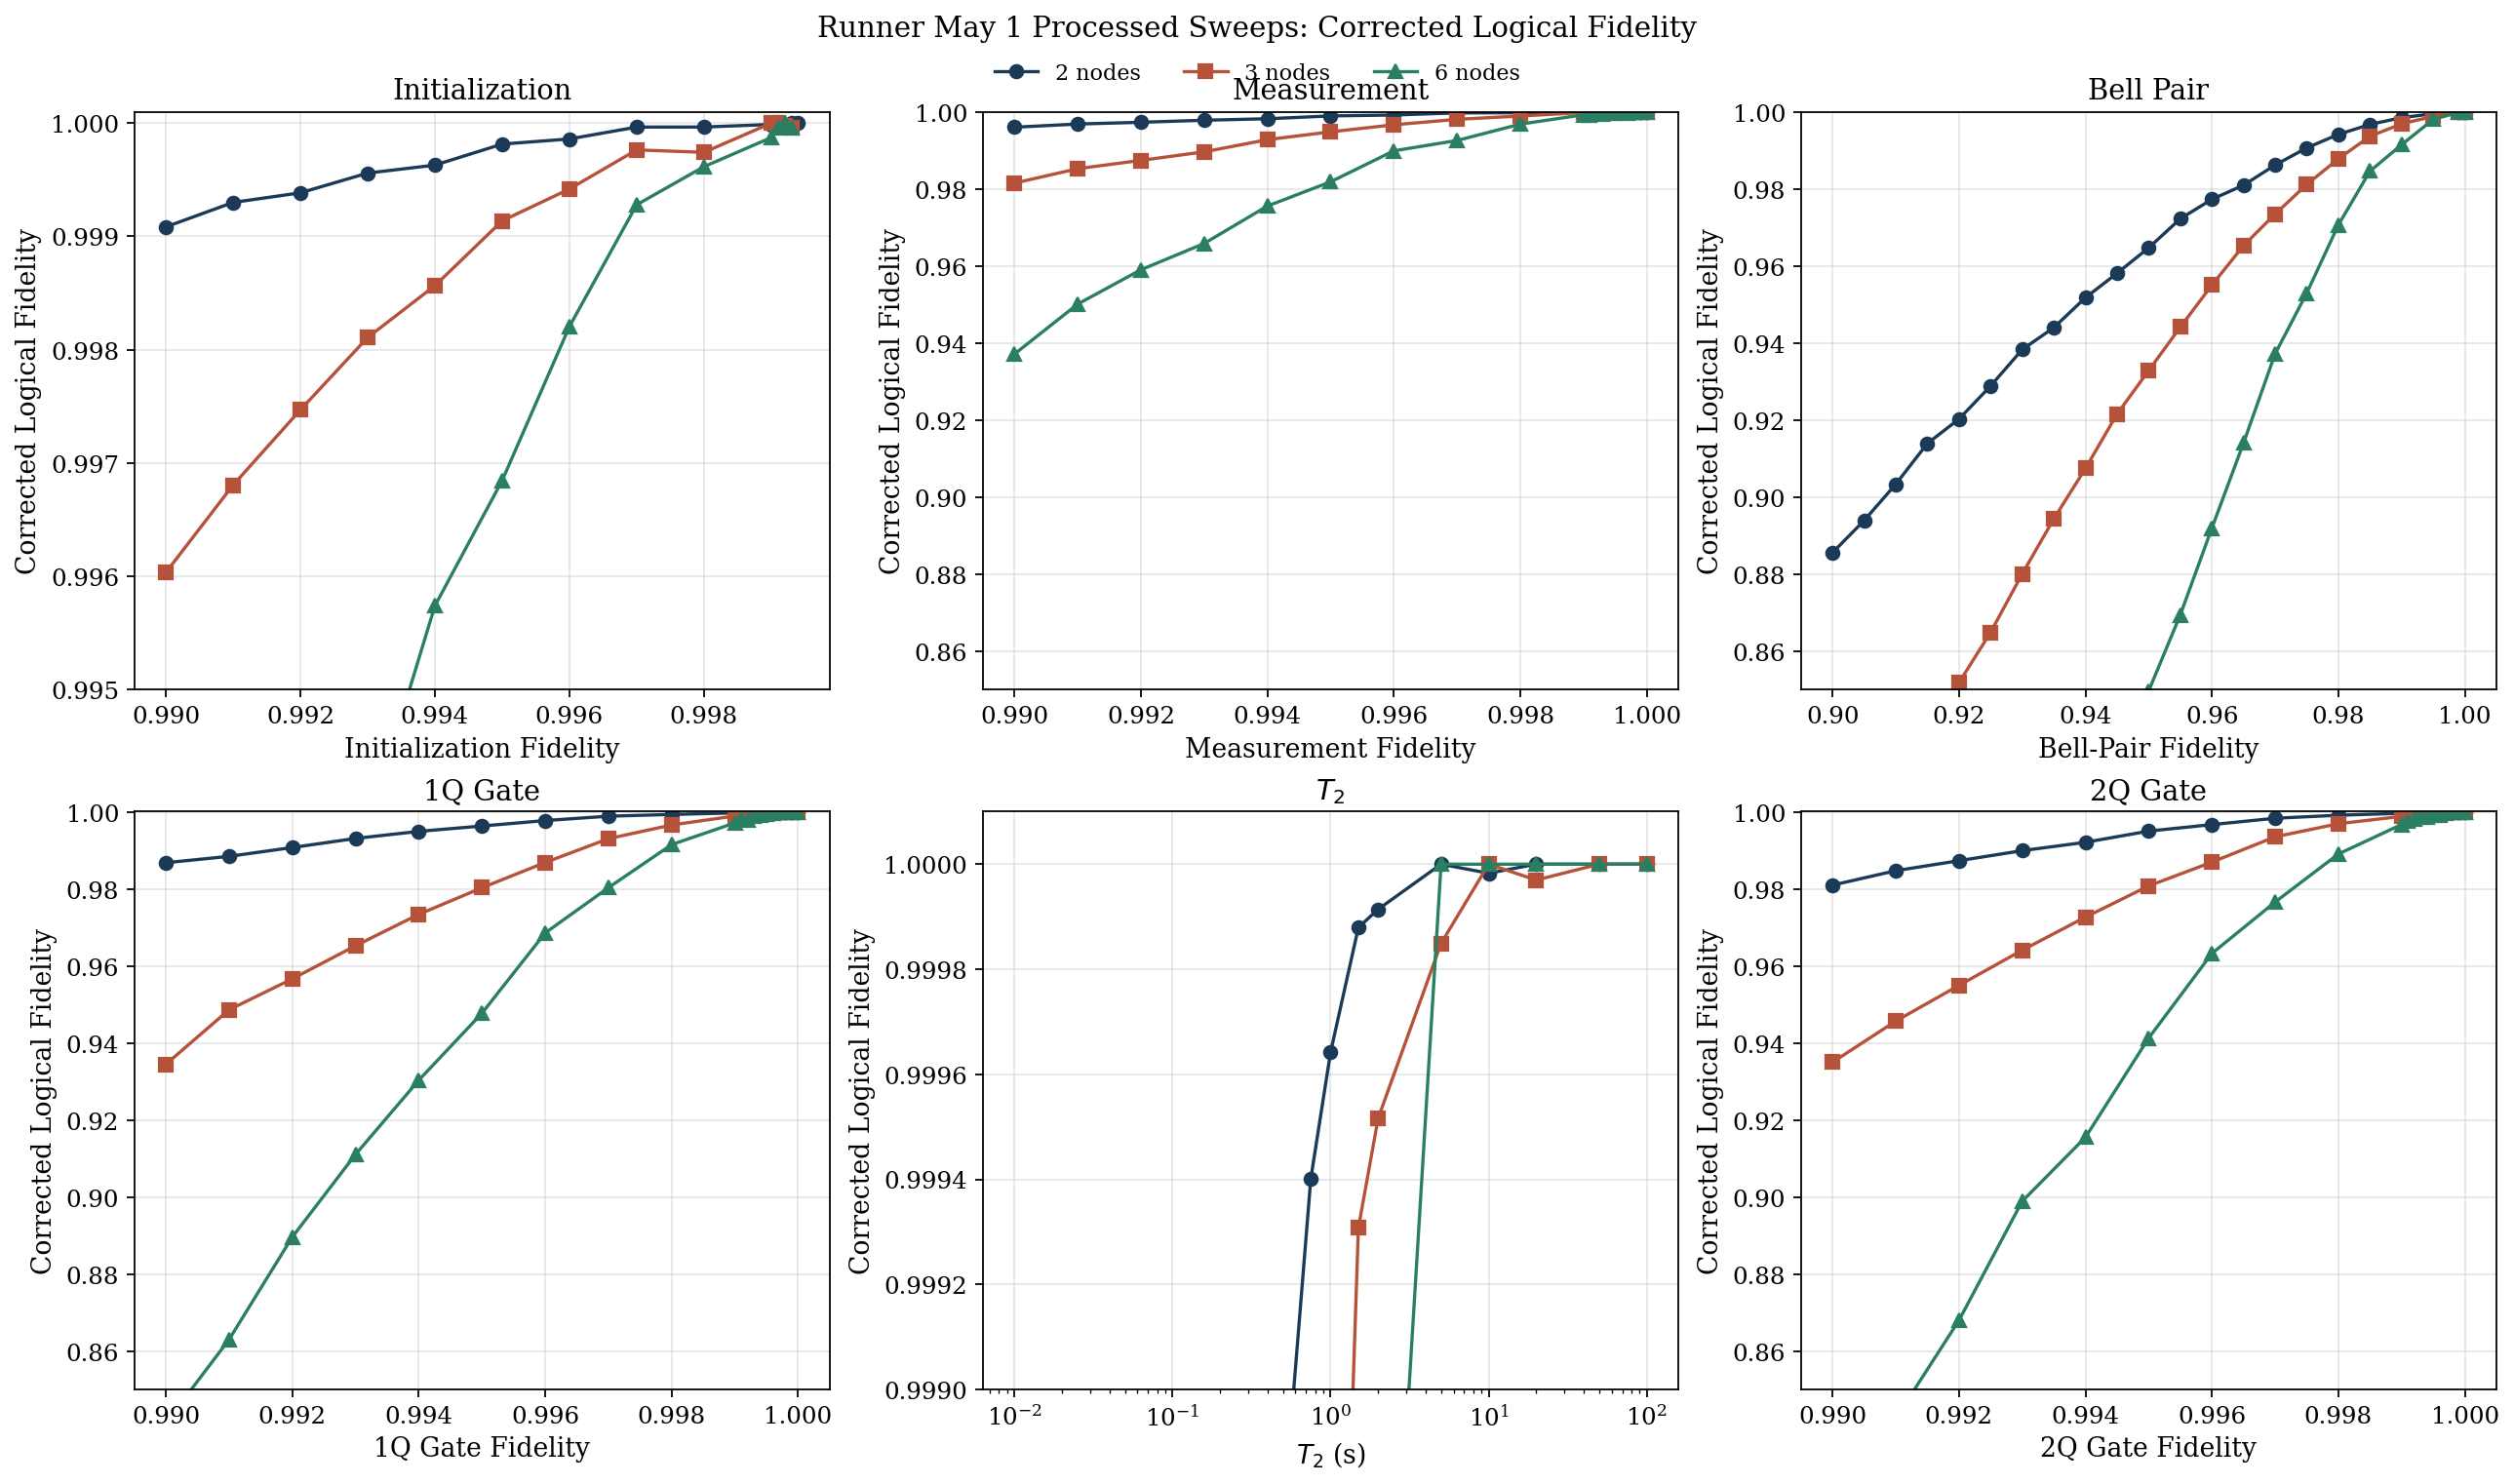

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for nodes in sorted(init_df["nodes"].unique()):
    d = init_df[init_df["nodes"] == nodes]
    axes[0, 0].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
axes[0, 0].set_title("Initialization")
axes[0, 0].set_xlabel("Initialization Fidelity")
axes[0, 0].set_ylabel("Corrected Logical Fidelity")
axes[0, 0].set_ylim(0.995, 1.0001)
axes[0, 0].grid(True, alpha=0.3)

for nodes in sorted(meas_df["nodes"].unique()):
    d = meas_df[meas_df["nodes"] == nodes]
    axes[0, 1].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
axes[0, 1].set_title("Measurement")
axes[0, 1].set_xlabel("Measurement Fidelity")
axes[0, 1].set_ylabel("Corrected Logical Fidelity")
axes[0, 1].set_ylim(0.85, 1.0001)
axes[0, 1].grid(True, alpha=0.3)

for nodes in sorted(bell_df["nodes"].unique()):
    d = bell_df[bell_df["nodes"] == nodes]
    axes[0, 2].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
axes[0, 2].set_title("Bell Pair")
axes[0, 2].set_xlabel("Bell-Pair Fidelity")
axes[0, 2].set_ylabel("Corrected Logical Fidelity")
axes[0, 2].set_ylim(0.85, 1.0001)
axes[0, 2].grid(True, alpha=0.3)

for nodes in sorted(oneq_df["nodes"].unique()):
    d = oneq_df[oneq_df["nodes"] == nodes]
    axes[1, 0].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
axes[1, 0].set_title("1Q Gate")
axes[1, 0].set_xlabel("1Q Gate Fidelity")
axes[1, 0].set_ylabel("Corrected Logical Fidelity")
axes[1, 0].set_ylim(0.85, 1.0001)
axes[1, 0].grid(True, alpha=0.3)

for nodes in sorted(t2_df["nodes"].unique()):
    d = t2_df[t2_df["nodes"] == nodes]
    axes[1, 1].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
axes[1, 1].set_title(r"$T_2$")
axes[1, 1].set_xlabel(r"$T_2$ (s)")
axes[1, 1].set_ylabel("Corrected Logical Fidelity")
axes[1, 1].set_xscale("log")
axes[1, 1].set_ylim(0.999, 1.0001)
axes[1, 1].grid(True, alpha=0.3)

for nodes in sorted(twoq_df["nodes"].unique()):
    d = twoq_df[twoq_df["nodes"] == nodes]
    axes[1, 2].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
axes[1, 2].set_title("2Q Gate")
axes[1, 2].set_xlabel("2Q Gate Fidelity")
axes[1, 2].set_ylabel("Corrected Logical Fidelity")
axes[1, 2].set_ylim(0.85, 1.0001)
axes[1, 2].grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Runner May 1 Processed Sweeps: Corrected Logical Fidelity", y=1.04)

fig.savefig("/Users/patange/Documents/Argonne/QEC/plot_pngs/graph1_abcdef_fidelity_grid.png")
fig.savefig("/Users/patange/Documents/Argonne/QEC/plot_pngs/graph1_abcdef_fidelity_grid.pdf")
plt.show()

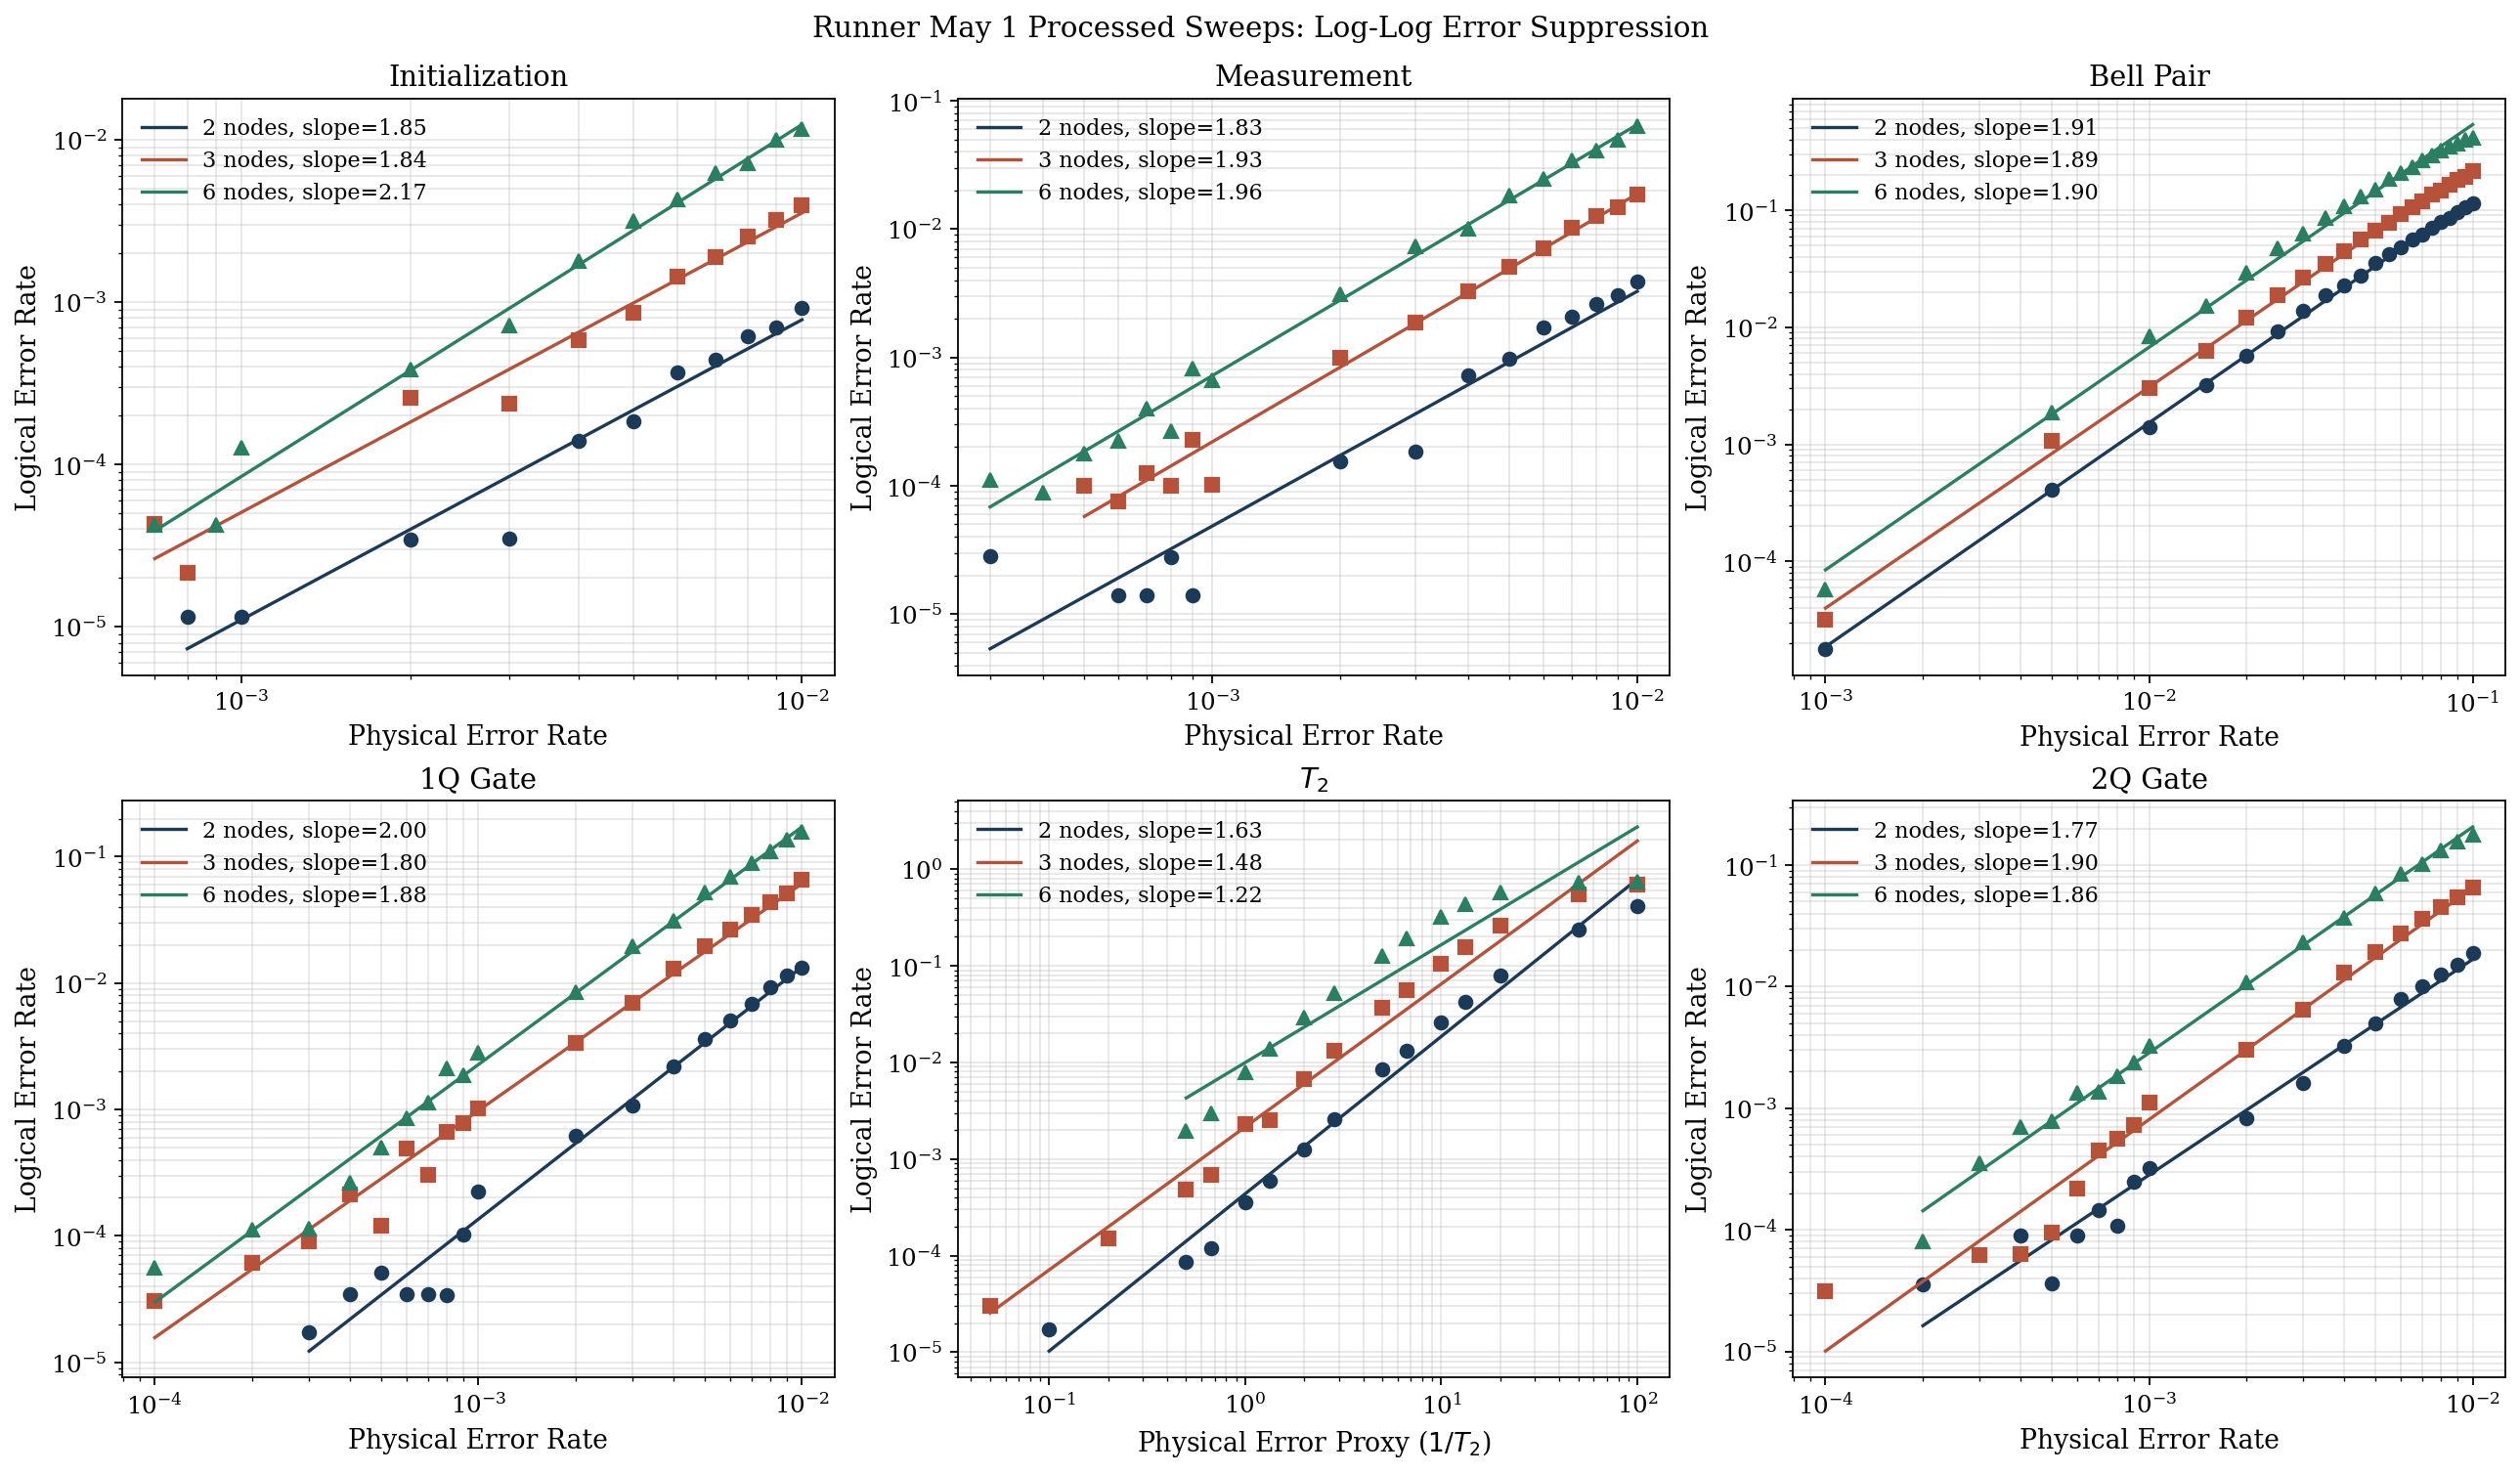

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for nodes in sorted(init_df["nodes"].unique()):
    d = init_df[init_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[0, 0].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes])
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[0, 0].plot(xfit, yfit, color=node_colors[nodes], label=f"{nodes} nodes, slope={coeffs[0]:.2f}")
axes[0, 0].set_xscale("log")
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Initialization")
axes[0, 0].set_xlabel("Physical Error Rate")
axes[0, 0].set_ylabel("Logical Error Rate")
axes[0, 0].grid(True, which="both", alpha=0.3)
axes[0, 0].legend(frameon=False)

for nodes in sorted(meas_df["nodes"].unique()):
    d = meas_df[meas_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[0, 1].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes])
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[0, 1].plot(xfit, yfit, color=node_colors[nodes], label=f"{nodes} nodes, slope={coeffs[0]:.2f}")
axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Measurement")
axes[0, 1].set_xlabel("Physical Error Rate")
axes[0, 1].set_ylabel("Logical Error Rate")
axes[0, 1].grid(True, which="both", alpha=0.3)
axes[0, 1].legend(frameon=False)

for nodes in sorted(bell_df["nodes"].unique()):
    d = bell_df[bell_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[0, 2].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes])
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[0, 2].plot(xfit, yfit, color=node_colors[nodes], label=f"{nodes} nodes, slope={coeffs[0]:.2f}")
axes[0, 2].set_xscale("log")
axes[0, 2].set_yscale("log")
axes[0, 2].set_title("Bell Pair")
axes[0, 2].set_xlabel("Physical Error Rate")
axes[0, 2].set_ylabel("Logical Error Rate")
axes[0, 2].grid(True, which="both", alpha=0.3)
axes[0, 2].legend(frameon=False)

for nodes in sorted(oneq_df["nodes"].unique()):
    d = oneq_df[oneq_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 0].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes])
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 0].plot(xfit, yfit, color=node_colors[nodes], label=f"{nodes} nodes, slope={coeffs[0]:.2f}")
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("1Q Gate")
axes[1, 0].set_xlabel("Physical Error Rate")
axes[1, 0].set_ylabel("Logical Error Rate")
axes[1, 0].grid(True, which="both", alpha=0.3)
axes[1, 0].legend(frameon=False)

for nodes in sorted(t2_df["nodes"].unique()):
    d = t2_df[t2_df["nodes"] == nodes].copy()
    x = 1.0 / d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 1].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes])
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 1].plot(xfit, yfit, color=node_colors[nodes], label=f"{nodes} nodes, slope={coeffs[0]:.2f}")
axes[1, 1].set_xscale("log")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title(r"$T_2$")
axes[1, 1].set_xlabel(r"Physical Error Proxy ($1/T_2$)")
axes[1, 1].set_ylabel("Logical Error Rate")
axes[1, 1].grid(True, which="both", alpha=0.3)
axes[1, 1].legend(frameon=False)

for nodes in sorted(twoq_df["nodes"].unique()):
    d = twoq_df[twoq_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 2].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes])
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 2].plot(xfit, yfit, color=node_colors[nodes], label=f"{nodes} nodes, slope={coeffs[0]:.2f}")
axes[1, 2].set_xscale("log")
axes[1, 2].set_yscale("log")
axes[1, 2].set_title("2Q Gate")
axes[1, 2].set_xlabel("Physical Error Rate")
axes[1, 2].set_ylabel("Logical Error Rate")
axes[1, 2].grid(True, which="both", alpha=0.3)
axes[1, 2].legend(frameon=False)

fig.suptitle("Runner May 1 Processed Sweeps: Log-Log Error Suppression", y=1.03)
fig.savefig("/Users/patange/Documents/Argonne/QEC/plot_pngs/graph1_abcdef_suppression_grid.png")
fig.savefig("/Users/patange/Documents/Argonne/QEC/plot_pngs/graph1_abcdef_suppression_grid.pdf")
plt.show()